# Exercise 1 — Notebook 3: Risk Indicators

## Purpose of this notebook

This notebook answers Task 1.2 of the exercise: compute relevant credit risk 
indicators for the portfolio, and explain the trends observed.

We build six indicators, each with an explanation of what it measures and 
why it matters, followed by the calculation, followed by interpretation:

1. **Default rate** — monthly flow and cumulative annual versions
2. **Repayment ratio trend** — portfolio-level, and cut by behavioural segment
3. **Utilisation ratio trend** — portfolio-level (revisited from notebook 2)
4. **Total credit exposure** — drawn and undrawn, directly answering the 
   Bank's stated question about exposure to this client group
5. **Roll rate transition matrix** — how customers migrate between 
   delinquency buckets month to month
6. **Pre-default utilisation trajectory** — comparing defaulters vs 
   non-defaulters in the months leading up to default, to explain *why* 
   the trends look the way they do

The roll rate matrix built here will also be reused directly in notebook 4 
for the 12-month forecast.M

## Step 1: Load the cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
df=pd.read_excel('data/cleaned_portfolio_data.xlsx')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Unique customers: {df['CustomerID'].nunique()}")
df.head(3)

Shape: 12000 rows, 18 columns
Unique customers: 1000


,CustomerID,ForDate,Age_FU,OpeningBalance,ClosingBalance,CreditLimit,MinPaymentAmount,Payments,MonthsPastDue,MonthsPastDue_num,MonthsPastDue_label,is_default,utilisation_ratio,repayment_ratio,repayment_ratio_capped,has_negative_payment,payment_compliance_ratio,payment_compliance_ratio_capped
0,ID1,2022-10-01,9,158.01,233.13,6000,30.0,30.00,0,0,0,False,0.038855,0.189861,0.189861,False,1.000000,1.000000
1,ID1,2022-11-01,10,233.13,453.95,6000,30.0,793.50,0,0,0,False,0.075658,3.403680,3.403680,False,26.450000,26.450000
2,ID1,2022-12-01,11,453.95,57.00,6000,30.0,521.09,0,0,0,False,0.009500,1.147902,1.147902,False,17.369667,17.369667


---

## Indicator 1: Default rate

We compute two distinct versions, because they measure different things:

- **Monthly default rate:** a flow concept what fraction of the *active* 
  portfolio is in default (MonthsPastDue = "4+") in a given month
- **Cumulative annual default rate:** a cohort outcome: what fraction of 
  the 1,000 customers *ever* reached default at any point during the year

Mixing these up is a common and meaningful mistake, so we keep them clearly 
separate throughout.

In [2]:
monthly_default=df.groupby('ForDate').agg(total_customers=('CustomerID', 'nunique'),
    defaulted_customers=('is_default', 'sum')).reset_index()
monthly_default['monthly_default_rate_pct'] = (monthly_default['defaulted_customers'] / monthly_default['total_customers'] * 100).round(2)
print(monthly_default)

      ForDate  total_customers  defaulted_customers  monthly_default_rate_pct
0  2022-10-01             1000                    0                       0.0
1  2022-11-01             1000                   16                       1.6
2  2022-12-01             1000                   28                       2.8
3  2023-01-01             1000                   42                       4.2
4  2023-02-01             1000                   55                       5.5
5  2023-03-01             1000                   64                       6.4
6  2023-04-01             1000                   70                       7.0
7  2023-05-01             1000                   80                       8.0
8  2023-06-01             1000                   88                       8.8
9  2023-07-01             1000                   90                       9.0
10 2023-08-01             1000                  100                      10.0
11 2023-09-01             1000                  102             

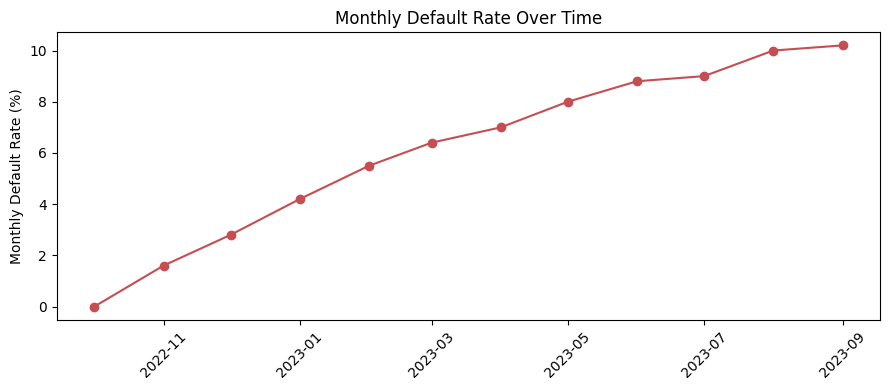

In [3]:
plt.figure(figsize=(9,4))
plt.plot(monthly_default['ForDate'],monthly_default['monthly_default_rate_pct'], 
         marker='o',color='#C44E52')
plt.ylabel('Monthly Default Rate (%)')
plt.title('Monthly Default Rate Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/monthly_default_rate.png', dpi=150)
plt.show()

### New default formation rate (the true monthly flow)

To isolate the flow rather than the stock, we compute: of the customers who 
were **not yet** in default at the start of a given month, what percentage 
newly entered default *that specific month*? This tells us whether the pace 
of new defaults is rising, falling, or stable the more genuinely 
forward-looking KRI for monitoring purposes.

In [4]:
df_sorted_flow=df.sort_values(['CustomerID','ForDate']).copy()
df_sorted_flow['was_default_last_month']=df_sorted_flow.groupby('CustomerID')['is_default'].shift(1).fillna(False)
#A "new" default this month: in default now, but was NOT in default last month
df_sorted_flow['new_default']=df_sorted_flow['is_default']&(~df_sorted_flow['was_default_last_month'])
new_default_flow=df_sorted_flow.groupby('ForDate').agg(population_at_risk=('was_default_last_month',lambda x:(~x).sum()),  # not yet defaulted going into this month
    new_defaults=('new_default','sum')).reset_index()
new_default_flow['new_default_rate_pct']=(new_default_flow['new_defaults'] / new_default_flow['population_at_risk'] * 100).round(2)
print(new_default_flow)

      ForDate  population_at_risk  new_defaults  new_default_rate_pct
0  2022-10-01                1000             0                  0.00
1  2022-11-01                1000            16                  1.60
2  2022-12-01                 984            12                  1.22
3  2023-01-01                 972            14                  1.44
4  2023-02-01                 958            15                  1.57
5  2023-03-01                 945             9                  0.95
6  2023-04-01                 936             6                  0.64
7  2023-05-01                 930            10                  1.08
8  2023-06-01                 920             9                  0.98
9  2023-07-01                 912             3                  0.33
10 2023-08-01                 910            10                  1.10
11 2023-09-01                 900             2                  0.22


/var/folders/55/gdfkn5kn6ls04m5tkp4r63800000gn/T/ipykernel_57253/2687811450.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sorted_flow['was_default_last_month']=df_sorted_flow.groupby('CustomerID')['is_default'].shift(1).fillna(False)


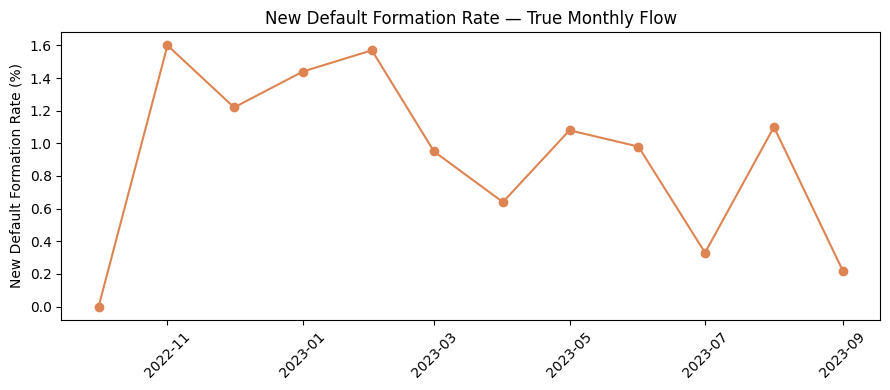

In [5]:
plt.figure(figsize=(9,4))
plt.plot(new_default_flow['ForDate'],new_default_flow['new_default_rate_pct'],marker='o', color='#DD8452')
plt.ylabel('New Default Formation Rate (%)')
plt.title('New Default Formation Rate — True Monthly Flow')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/new_default_formation_rate.png', dpi=150)
plt.show()

**Interpretation:** 

The rate of new defaults tells a different and much more encouraging story than the total, accumulating default rate.New defaults peaked early at 1.6% in November 2022 and stayed high through February 2023. After that, they steadily dropped, hitting just 0.22% by September.This explains why the total default chart kept climbing. It wasn't because risk was accelerating, but because a huge wave of early defaults stacked up. Since almost no one paid off their debt to fix their default status, even the smaller number of new monthly defaults kept adding to that permanent pile. The actual pace of new risk entering the bank has been improving since March 2023.This distinction is crucial for business decisions. A team looking only at total defaults would wrongly assume the portfolio is constantly getting worse. Tracking new defaults instead proves that the actual creation of risk has slowed down significantly.

Each month, I calculate a separate, independent default rate.To do this, I look only at customers who had not defaulted yet at the start of the month. Then, I find what percentage of those specific people newly defaulted during that month.The total number of people I check gets smaller every month. This happens because once a customer defaults, they are permanently removed from the test group. This step keeps each month’s number clean and accurate, instead of getting mixed up with past months.

`Note`

the at-risk population is 
not a simple running subtraction of cumulative defaulters from 1,000 — it is 
recalculated each month from each customer's actual status, which correctly 
allows for the rare case of a customer **curing** (returning to a non-default 
status after having reached "4+"). We confirmed this directly: across the 
full dataset, exactly **4 cure events** occur (customers `ID357`, `ID378`, 
`ID720`, `ID817`), consistent with the data dictionary's note that the 
majority not all of defaulted customers fail to return to a lower 
past-due status. One of these cures (`ID817`, July 2023) explains a small, 
expected upward adjustment in that month's at-risk population, rather than 
the simple month-on-month subtraction one might otherwise expect.

**How this helps, and what action it supports:** This is the metric that 
should actually be tracked as an ongoing KRI, not the cumulative default 
rate. Because it isolates the genuine monthly inflow of new risk, a rising 
new default formation rate would be a real, timely trigger for escalation, 
while the cumulative rate alone would always show "deteriorating" even when 
the underlying risk-generation process is actually improving, as it was here.

### Cumulative annual default rate

This is the headline cohort-level number: of all 1,000 customers, what 
fraction ever reached default during the full 12-month window? Each 
customer is counted once, regardless of how many months they spent in 
default.

In [6]:
ever_defaulted=df.groupby('CustomerID')['is_default'].max()
n_defaulted=ever_defaulted.sum()
n_total=len(ever_defaulted)
cumulative_default_rate=n_defaulted/n_total*100
print(f"Customers who ever defaulted during the year: {n_defaulted} out of {n_total}")
print(f"Cumulative annual default rate: {cumulative_default_rate:.2f}%")

Customers who ever defaulted during the year: 105 out of 1000
Cumulative annual default rate: 10.50%


**Interpretation**

Over the full year, 105 out of 1,000 customers or 10.5% defaulted at least once.This is slightly higher than the 10.2% shown in the September snapshot. This small difference happens because of the customers who fixed their accounts earlier in the year. They are correctly counted in this full-year total, but they would not show up in a single snapshot taken at the end of the year.

---

## Indicator 2: Repayment ratio as a portfolio-level KRI

We already classified customers into Transactor/Revolver/Mixed in notebook 2 
using their full-year average repayment ratio. Here we look at the 
**portfolio-level monthly trend** instead, and to tie the two notebooks 
together cut that trend by behavioural segment, since we already know 
Revolvers carry materially higher default risk.

In [7]:
# Rebuild the segment classification (same logic as notebook 2) so this notebook is self-contained
customer_segment=df.groupby('CustomerID').agg(avg_repayment_ratio=('repayment_ratio_capped', 'mean')).reset_index()

def behaviour_segment(r):
    if pd.isna(r):
        return 'Insufficient Data'
    elif r>=0.9:
        return 'Transactor'
    elif r<0.3:
        return 'Revolver'
    else:
        return 'Mixed'

customer_segment['segment']=customer_segment['avg_repayment_ratio'].apply(behaviour_segment)
# Merge segment label back onto the monthly panel
df=df.merge(customer_segment[['CustomerID','segment']],on='CustomerID',how='left')
# Portfolio-level monthly repayment ratio trend, overall and by segment
monthly_repayment_overall=df.groupby('ForDate')['repayment_ratio_capped'].mean()
monthly_repayment_by_segment=df.groupby(['ForDate','segment'])['repayment_ratio_capped'].mean().unstack()
print("Overall monthly repayment ratio:")
print(monthly_repayment_overall)

Overall monthly repayment ratio:
ForDate
2022-10-01    0.814364
2022-11-01    0.703385
2022-12-01    0.722851
2023-01-01    0.761981
2023-02-01    0.762356
2023-03-01    0.739533
2023-04-01    0.723012
2023-05-01    0.786850
2023-06-01    0.754490
2023-07-01    0.670158
2023-08-01    0.552661
2023-09-01    0.647817
Name: repayment_ratio_capped, dtype: float64


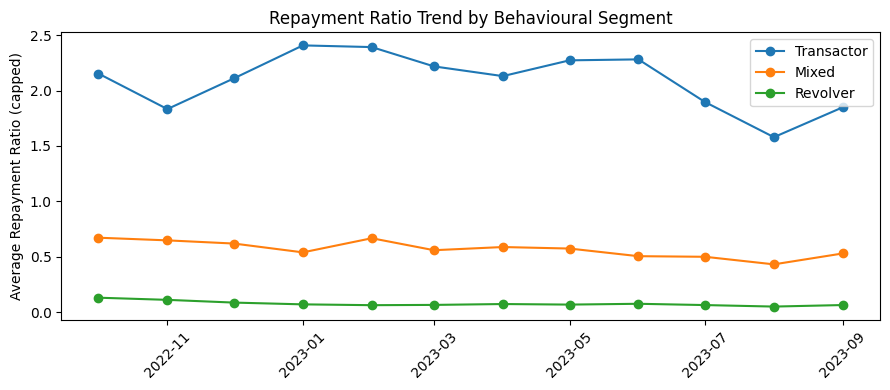

In [8]:
plt.figure(figsize=(9, 4))
for segment in ['Transactor','Mixed','Revolver']:
    plt.plot(monthly_repayment_by_segment.index,monthly_repayment_by_segment[segment],marker='o',label=segment)
plt.ylabel('Average Repayment Ratio (capped)')
plt.title('Repayment Ratio Trend by Behavioural Segment')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('figures/repayment_ratio_by_segment_trend.png', dpi=150)
plt.show()

**Interpretation**


This confirms the segment finding from my earlier analysis is genuinely structural, not just a yearly average. Looking month by month, the three behavioural groups never cross — Transactors stay consistently high, Revolvers stay consistently low and almost flat, all twelve months. That flatness for Revolvers is the key point: it's not occasional struggling, it's a stable, predictable pattern, which is exactly consistent with why that segment carries such a higher default rate.

**How this helps, and what action it supports:** Because this gap is 
structural and persistent rather than seasonal, repayment ratio could be 
monitored as a standing, automatically-refreshed KRI per segment, with the 
Revolver segment's threshold set tighter than the portfolio average — 
triggering review sooner for this group specifically, since "normal" 
Revolver behaviour already carries materially higher risk than "normal" 
behaviour elsewhere in the book.

---

## Indicator 3: Total credit exposure

This indicator answers the Bank's explicit question directly: *"what is its 
credit exposure towards this client group?"* We compute two components:

- **Total drawn exposure** — the sum of `ClosingBalance` across all customers 
  each month: money currently outstanding and at risk
- **Total undrawn exposure** — the sum of (`CreditLimit` minus `ClosingBalance`) 
  across all customers: credit that has been approved but not yet used. This 
  matters because undrawn limits are also a regulatory exposure concept 
  (related to Exposure at Default under Basel) — they can be drawn down 
  before or at the point of default, so they are not risk-free just because 
  they're currently unused.

In [9]:
monthly_exposure=df.groupby('ForDate').agg(total_drawn_exposure=('ClosingBalance','sum'),
    total_credit_limit=('CreditLimit','sum')).reset_index()

monthly_exposure['total_undrawn_exposure']=(monthly_exposure['total_credit_limit'] - monthly_exposure['total_drawn_exposure'])
print(monthly_exposure)
print()
print(f"End-of-period total drawn exposure: EUR {monthly_exposure['total_drawn_exposure'].iloc[-1]:,.0f}")
print(f"End-of-period total undrawn exposure: EUR {monthly_exposure['total_undrawn_exposure'].iloc[-1]:,.0f}")

      ForDate  total_drawn_exposure  total_credit_limit  total_undrawn_exposure
0  2022-10-01             813494.21             2356450              1542955.79
1  2022-11-01             887529.04             2551450              1663920.96
2  2022-12-01             972294.74             2738750              1766455.26
3  2023-01-01             999934.61             2863450              1863515.39
4  2023-02-01            1045175.30             2994950              1949774.70
5  2023-03-01            1071685.79             3098950              2027264.21
6  2023-04-01            1110474.26             3210150              2099675.74
7  2023-05-01            1142152.49             3317950              2175797.51
8  2023-06-01            1221535.88             3381850              2160314.12
9  2023-07-01            1237912.15             3420450              2182537.85
10 2023-08-01            1309805.95             3468550              2158744.05
11 2023-09-01            1324911.44     

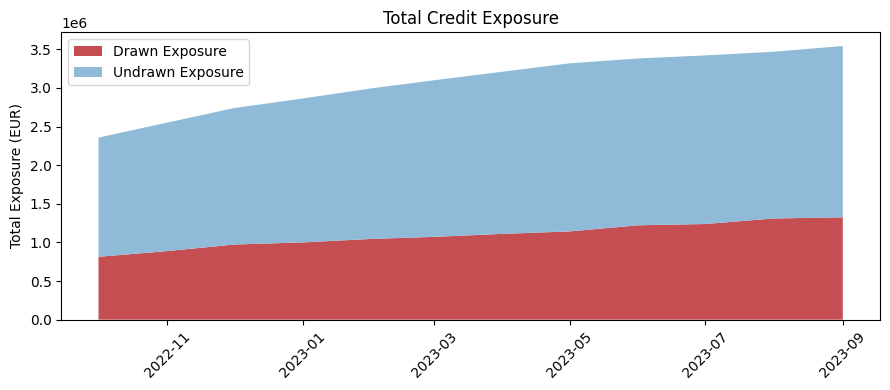

In [10]:
plt.figure(figsize=(9, 4))
plt.stackplot(monthly_exposure['ForDate'], 
              monthly_exposure['total_drawn_exposure'], 
              monthly_exposure['total_undrawn_exposure'],
              labels=['Drawn Exposure','Undrawn Exposure'],
              colors=['#C44E52', '#8FBBD9'])
plt.ylabel('Total Exposure (EUR)')
plt.title('Total Credit Exposure')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('figures/total_credit_exposure.png', dpi=150)
plt.show()

This directly answers the Bank's question about credit exposure.Used credit grew 63% over the year to about €1.3 million. However, unused credit-approved credit lines that customers haven't used yet was actually larger the entire time, ending at over €2.2 million. This unused amount matters because it is not risk-free. Customers can spend it very quickly, even right before they default.This also explains a confusing point from my earlier analysis. Total credit limits grew about 50% over the year, which matched the growth of used credit. Because they grew together, the usage ratio looked flat and hidden, even though the actual amount of money at risk was growing heavily. This proves you need to look at both the percentage ratio and the actual dollar numbers to see the full picture.

**How this helps, and what action it supports:** Tracking undrawn exposure 
alongside drawn exposure matters directly for capital and liquidity 
planning — if undrawn limits were suddenly drawn down, the Bank's exposure could grow well beyond the current 
drawn figure. This supports a concrete action: factoring a credit conversion 
assumption (what % of undrawn limits would likely be drawn in a stress) into 
stress testing and capital planning, rather than treating undrawn exposure 
as zero-risk simply because it is currently unused.

---

## Indicator 4: Roll rate transition matrix

This is the centrepiece risk methodology in this notebook, it is how real 
credit risk teams track delinquency migration, and it directly explains 
*why* default rate trends move the way they do, since it shows exactly which 
month-to-month transition is driving change.

**What we're building:** for every customer-month, we look at their 
`MonthsPastDue` bucket this month and their bucket *next* month, and count 
how often each transition occurs. This produces a matrix: rows are "current 
state," columns are "next state," and each cell is the probability of moving 
from one to the other.

We treat "4+ (Default)" as effectively an absorbing state for this analysis, 
consistent with the data dictionary's own note that the majority of 
customers who reach 4+ do not return to a lower past-due status.

In [11]:
#Sort and build a "next month" state for each customer using shift, grouped by customer
df_sorted=df.sort_values(['CustomerID', 'ForDate']).copy()
df_sorted['next_state']=df_sorted.groupby('CustomerID')['MonthsPastDue_label'].shift(-1)
#Keep only rows where we actually observe a next month (drops each customer's last month)
transitions=df_sorted.dropna(subset=['next_state'])
print(f"Total transition observations: {len(transitions)}")
transitions[['CustomerID','ForDate','MonthsPastDue_label','next_state']].head(10)

Total transition observations: 11000


,CustomerID,ForDate,MonthsPastDue_label,next_state
0,ID1,2022-10-01,0,0
1,ID1,2022-11-01,0,0
2,ID1,2022-12-01,0,0
3,ID1,2023-01-01,0,0
4,ID1,2023-02-01,0,0
5,ID1,2023-03-01,0,0
6,ID1,2023-04-01,0,0
7,ID1,2023-05-01,0,0
8,ID1,2023-06-01,0,0
9,ID1,2023-07-01,0,0


In [12]:
#cross-tabulate current state vs next state, normalised by row (so each row sums to 1 = probabilities)
transition_matrix=pd.crosstab(
    transitions['MonthsPastDue_label'], 
    transitions['next_state'], 
    normalize='index')

#Reorder rows and columns logically: 0, 1, 2, 3, 4+ (Default)
state_order=['0', '1', '2', '3', '4+ (Default)']
transition_matrix=transition_matrix.reindex(index=state_order,columns=state_order)
print("Transition matrix (row = current state, column = next month's state):")
print((transition_matrix*100).round(1))

Transition matrix (row = current state, column = next month's state):
next_state              0    1     2     3  4+ (Default)
MonthsPastDue_label                                     
0                    94.0  6.0   0.0   0.0           0.0
1                    61.6  8.6  29.9   0.0           0.0
2                    29.6  6.1   4.2  59.6           0.5
3                    17.3  2.2   2.2   2.9          75.5
4+ (Default)          0.5  0.0   0.2   0.0          99.4


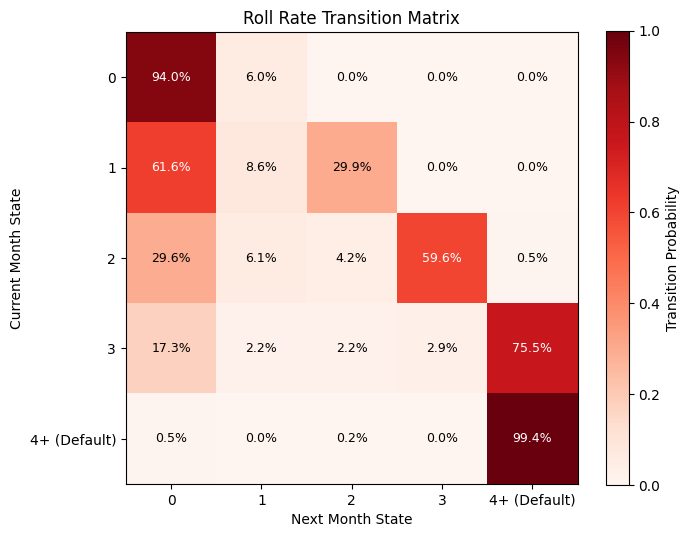

In [13]:
fig,ax=plt.subplots(figsize=(7,5.5))
im=ax.imshow(transition_matrix.values,cmap='Reds',vmin=0,vmax=1)
ax.set_xticks(range(len(state_order)))
ax.set_yticks(range(len(state_order)))
ax.set_xticklabels(state_order)
ax.set_yticklabels(state_order)
ax.set_xlabel('Next Month State')
ax.set_ylabel('Current Month State')
ax.set_title('Roll Rate Transition Matrix')
#annotate each cell with its value
for i in range(len(state_order)):
    for j in range(len(state_order)):
        val=transition_matrix.values[i,j]
        if not np.isnan(val):
            ax.text(j, i, f"{val*100:.1f}%",ha='center',va='center', 
                     color='white' if val>0.5 else 'black', fontsize=9)
plt.colorbar(im,ax=ax,label='Transition Probability')
plt.tight_layout()
plt.savefig('figures/roll_rate_transition_matrix.png',dpi=150)
plt.show()

**Interpretation**

This matrix shows the real tipping point in this portfolio's delinquency behaviour. Being one month late is mostly temporary over 60% cure immediately. But two months late is where it flips: only 30% recover, and 60% roll forward to three months late. After that, recovery is rare, 75% of three months late customers go straight to default. And default itself is almost permanent, 99.4% stay there. Practically, this tells the risk team exactly where to focus collections effort the two month bucket is the real inflection point, not one month, which mostly fixes itself anyway.



**How this helps, and what action it supports:** This pinpoints exactly 
where collections effort is most efficiently spent. Since 1-month-past-due 
accounts mostly self-correct without intervention, and 3-month-past-due 
accounts are largely already lost, the 2-month-past-due bucket is the 
highest-value intervention point a proactive outreach or repayment 
support programme targeted specifically at this stage would likely produce 
the largest reduction in eventual defaults per unit of collections effort 
spent.

---

## Explaining the trends — Part 1: the seasoning effect

One candidate explanation we flagged in notebook 2 is **seasoning**: 
do customers with lower tenure (`Age_FU`) at the start of the window show 
different default incidence than more seasoned customers?

**Methodological note:** tenure bands are based on each customer's *starting* 
`Age_FU` value at the beginning of the observation window, used purely to 
group customers into cohorts for comparison. They are not a time varying 
filter a customer's actual `Age_FU` continues increasing by one each month 
throughout the dataset, and their default (if any) can occur many months 
after their starting tenure band.

In [14]:
customer_tenure_default=df.sort_values(['CustomerID','ForDate']).groupby('CustomerID').agg(starting_age_fu=('Age_FU','first'),
    ever_default=('is_default', 'max')).reset_index()
#here basically we find the starting age for each customer, we use that age as tenure and then 
#we are simply trying to this starting age_fu customer tend to default or not. We are trying to find the relationship between starting age_fu and default rate.
#we make bucket tenure into bands for a clean comparison
def tenure_band(age):
    if age<=3:
        return '1-3 months (Newest)'
    elif 3<age<=6:
        return '4-6 months'
    elif 6<age<=9:
        return '7-9 months'
    else:
        return '10-12 months (Most Seasoned)'

customer_tenure_default['tenure_band']=customer_tenure_default['starting_age_fu'].apply(tenure_band)
tenure_order=['1-3 months (Newest)','4-6 months','7-9 months','10-12 months (Most Seasoned)']
seasoning_summary=customer_tenure_default.groupby('tenure_band')['ever_default'].agg(
    num_customers='count', default_rate='mean').reindex(tenure_order)
seasoning_summary['default_rate']=(seasoning_summary['default_rate']*100).round(2)
print(seasoning_summary)
print("default rate is in percentage")

                              num_customers  default_rate
tenure_band                                              
1-3 months (Newest)                     354         13.56
4-6 months                              270         12.22
7-9 months                              207          5.31
10-12 months (Most Seasoned)            169          7.69
default rate is in percentage


**Interpretation**

Newer customers: under 6 months tenure default at roughly twice the rate of more seasoned customers, about 13% versus 6%. This is a classic seasoning effect: riskier customers tend to reveal themselves early, so the ones who survive past the first few months are a self-screened, lower-risk group. It also ties back to my earlier finding that new defaults were concentrated early in the year

**How this helps, and what action it supports:** This supports tightening 
monitoring specifically for the first 6 months of a new customer's 
relationship for example, more conservative initial credit limits, or 
closer review before any early limit increase is approved, given that this 
window carries roughly double the default risk of more seasoned tenure.

---

## Explaining the trends — Part 2: pre-default utilisation trajectory

This is the strongest early warning analysis in this notebook. We compare 
how utilisation behaves in the months **leading up to default** for 
customers who eventually default, against the utilisation of customers who 
never default, aligned on a common timeline ("months before default" / 
"months before end of window").

If defaulters show a visible utilisation climb in the months before 
defaulting, that is direct evidence utilisation is a genuine leading 
indicator not just a correlate, but something that visibly moves before 
the bad outcome occurs.

In [15]:
#identify defaulting customers and the exact month they first hit "4+"
default_months=df[df['is_default']].groupby('CustomerID')['ForDate'].min().reset_index()
default_months.columns=['CustomerID','first_default_date']
defaulters=default_months['CustomerID'].unique()
non_defaulters=df[~df['CustomerID'].isin(defaulters)]['CustomerID'].unique()
print(f"Defaulting customers:{len(defaulters)}")
print(f"Non-defaulting customers:{len(non_defaulters)}")

#for defaulters: align each row to "months before default
df_def=df[df['CustomerID'].isin(defaulters)].merge(default_months,on='CustomerID')
df_def['months_before_default']=((df_def['first_default_date'].dt.year-df_def['ForDate'].dt.year) * 12 +
    (df_def['first_default_date'].dt.month-df_def['ForDate'].dt.month))

# Keep only the lead-up window: 6 months before default through the default month itself
defaulter_trajectory= (df_def[(df_def['months_before_default'] >= 0) & (df_def['months_before_default'] <= 6)]
    .groupby('months_before_default')['utilisation_ratio'].mean().sort_index(ascending=False))

#for non-defaulters: simple average utilisation across all months, for reference
non_defaulter_avg_utilisation=df[df['CustomerID'].isin(non_defaulters)]['utilisation_ratio'].mean()
print("\nDefaulter average utilisation, by months before default (6 = furthest out, 0 = default month):")
print(defaulter_trajectory)
print(f"\nNon-defaulter average utilisation (whole year, for reference): {non_defaulter_avg_utilisation:.3f}")

Defaulting customers:105
Non-defaulting customers:895

Defaulter average utilisation, by months before default (6 = furthest out, 0 = default month):
months_before_default
6    0.873957
5    0.858038
4    0.877835
3    0.950039
2    0.969502
1    0.989213
0    0.971160
Name: utilisation_ratio, dtype: float64

Non-defaulter average utilisation (whole year, for reference): 0.391


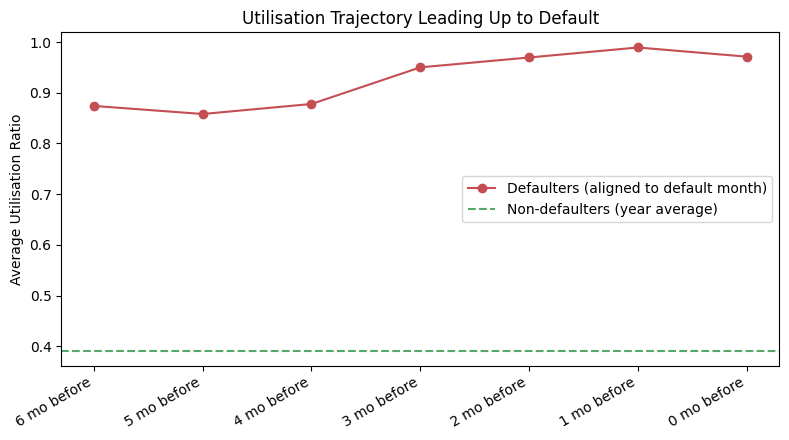

In [ ]:
plt.figure(figsize=(8, 4.5))
x_labels=defaulter_trajectory.index.astype(str)+' mo before'
plt.plot(range(len(defaulter_trajectory)), defaulter_trajectory.values, 
         marker='o',color='#C44E52',label='Defaulters (aligned to default month)')
plt.axhline(non_defaulter_avg_utilisation,color='#55A868',linestyle='--',label='Non-defaulters (year average)')
plt.xticks(range(len(defaulter_trajectory)),x_labels,rotation=30,ha='right')
plt.ylabel('Average Utilization Ratio')
plt.title('Utilization Trajectory Leading Up to Default')
plt.legend()
plt.tight_layout()
plt.savefig('figures/pre_default_utilisation_trajectory.png', dpi=150)
plt.show()

**Interpretation**

This is my most important finding: customers who eventually default are already using 87% of their available credit six months before it happens, which is more than double the 39% average for everyone else. This number keeps climbing until they are completely maxed out at nearly 99% just one month before default. Looking at this specific timeline fixes a mistake from my earlier analysis, where mixing the data from before and after default made the patterns look confusing. Now, the signal is completely clear: keeping credit usage this high for a long time is a genuine early warning sign that shows up months before anyone misses a payment, This is exactly the kind of pattern a KRI monitoring system should be built to catch

**How this helps, and what action it supports:** This is the most 
directly actionable finding in the notebook. A rule as simple as "flag any 
customer sustaining utilisation above 85% for two or more consecutive 
months" could be implemented immediately as a KRI, using data the Bank 
already collects monthly no new data infrastructure required. Customers 
flagged this way could be proactively contacted, offered a structured 
repayment plan, or have further credit limit increases paused, months 
before they would otherwise show up as past due.

## Summary of Task 1.2 findings

**Default rate:** The cumulative annual default rate is **10.50%** (105 of 
1,000 customers defaulted at least once), closely matching the September 
month-end snapshot of 10.2%, with the small gap explained by 4 confirmed 
cure events. Critically, the **stock** (cumulative in-default count) and 
**flow** (new default formation) tell different stories: the stock rate 
climbs steadily all year because "4+" is a near-absorbing state, but the 
flow rate shows new defaults actually **peaked early** (around 1.6% in 
November 2022) and **declined** through the year (to 0.22% by September) — 
the pace of new risk generation improved even as the cumulative total kept 
rising.

**Repayment ratio:** The Transactor/Revolver/Mixed gap identified in 
notebook 2 is **persistent across all 12 months**, never narrowing or 
converging — confirming this is a stable, structural behavioural trait 
rather than a seasonal or temporary pattern.

**Total credit exposure:** Drawn exposure grew from €813,494 to **€1,324,911** 
(63%) over the year; undrawn exposure — unused but approved credit — grew 
from €1,542,956 to **€2,217,539**, remaining larger than drawn exposure at 
every point in the year. This directly answers the Bank's question about 
credit exposure to this client group, and resolves the earlier utilisation-
ratio puzzle from notebook 2: credit limit grew roughly in step with drawn 
balance, which is why the ratio alone understated the real growth in exposure.

**Roll rate transition matrix:** The critical tipping point in delinquency 
behaviour is the **2-month-past-due bucket** — 1-month-past-due customers 
mostly self-correct (61.6% cure), but from 2 months onward the majority 
roll forward rather than recover (59.6% roll to 3 months; 75.5% of 3-month 
customers roll to default). Default itself is highly persistent (99.4% stay 
in default), consistent with the 4 confirmed cure events found elsewhere in 
this notebook.

**Seasoning effect:** Customers with under 6 months of starting tenure 
default at roughly **twice the rate** of more seasoned customers (≈13% vs 
≈6%), consistent with riskier customers revealing themselves early in the 
relationship.

**Pre-default utilisation trajectory:** The single strongest finding in 
this notebook. Defaulting customers run at **87% utilisation a full 6 
months before default** — more than double the 39% portfolio-wide average 
for non-defaulters — climbing to nearly **99%** one month before default. 
This resolves the non-monotonic utilisation-band finding from notebook 2 
(which blended pre- and post-default behaviour into one average) and proves 
utilisation is a genuine, actionable leading indicator, not just a correlate.

**Overall:** sustained high utilisation and Revolver-type repayment behaviour 
are the portfolio's clearest, most actionable early warning signals — both 
visible well before a customer's `MonthsPastDue` status changes. These 
findings, together with the roll rate transition matrix, carry forward 
directly into notebook 4, where the transition matrix becomes the engine 
for the 12-month forecast.